# Sınıf Ağırlıklandırma Deneyi (Class Weight Experiment)

Bu çalışmada, azınlık sınıfı olan **CL** (nakil sonrası yaşayan hastalar) sınıfının tahmin performansını artırmak amacıyla farklı sınıf ağırlıklandırma (class weight) stratejileri test edilmiştir.

### Deneyin Amaçları:
- **SMOTE** gibi sentetik veri üretme yöntemleri kullanmadan sadece `class_weight` hiperparametresi ile azınlık sınıfını yakalama başarısını incelemek.
- **CL** Recall ve F1 skorlarındaki değişimi gözlemlemek.
- Genel doğruluk (**Accuracy**) ve **Macro F1** skorlarındaki kaybı kontrol ederek en mantıklı dengeyi sunan `class_weight` ayarını seçmek.

### Test Edilecek Modeller:
- **Model A**: `class_weight="balanced"`
- **Model B**: `class_weight={0:1, 1:5, 2:1}` (0 = C, 1 = CL, 2 = D)
- **Model C**: `class_weight={0:1, 1:10, 2:1}`
- **Model D**: `class_weight={0:1, 1:15, 2:1}`


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="white", palette="muted")

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [2]:
# 1. Veri Yükleme
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")
print("Sınıf Dağılımı (Test Seti):")
print(y_test.value_counts())

Eğitim Seti Boyutu: (6324, 30)
Test Seti Boyutu: (1581, 30)
Sınıf Dağılımı (Test Seti):
Status
0    993
2    533
1     55
Name: count, dtype: int64


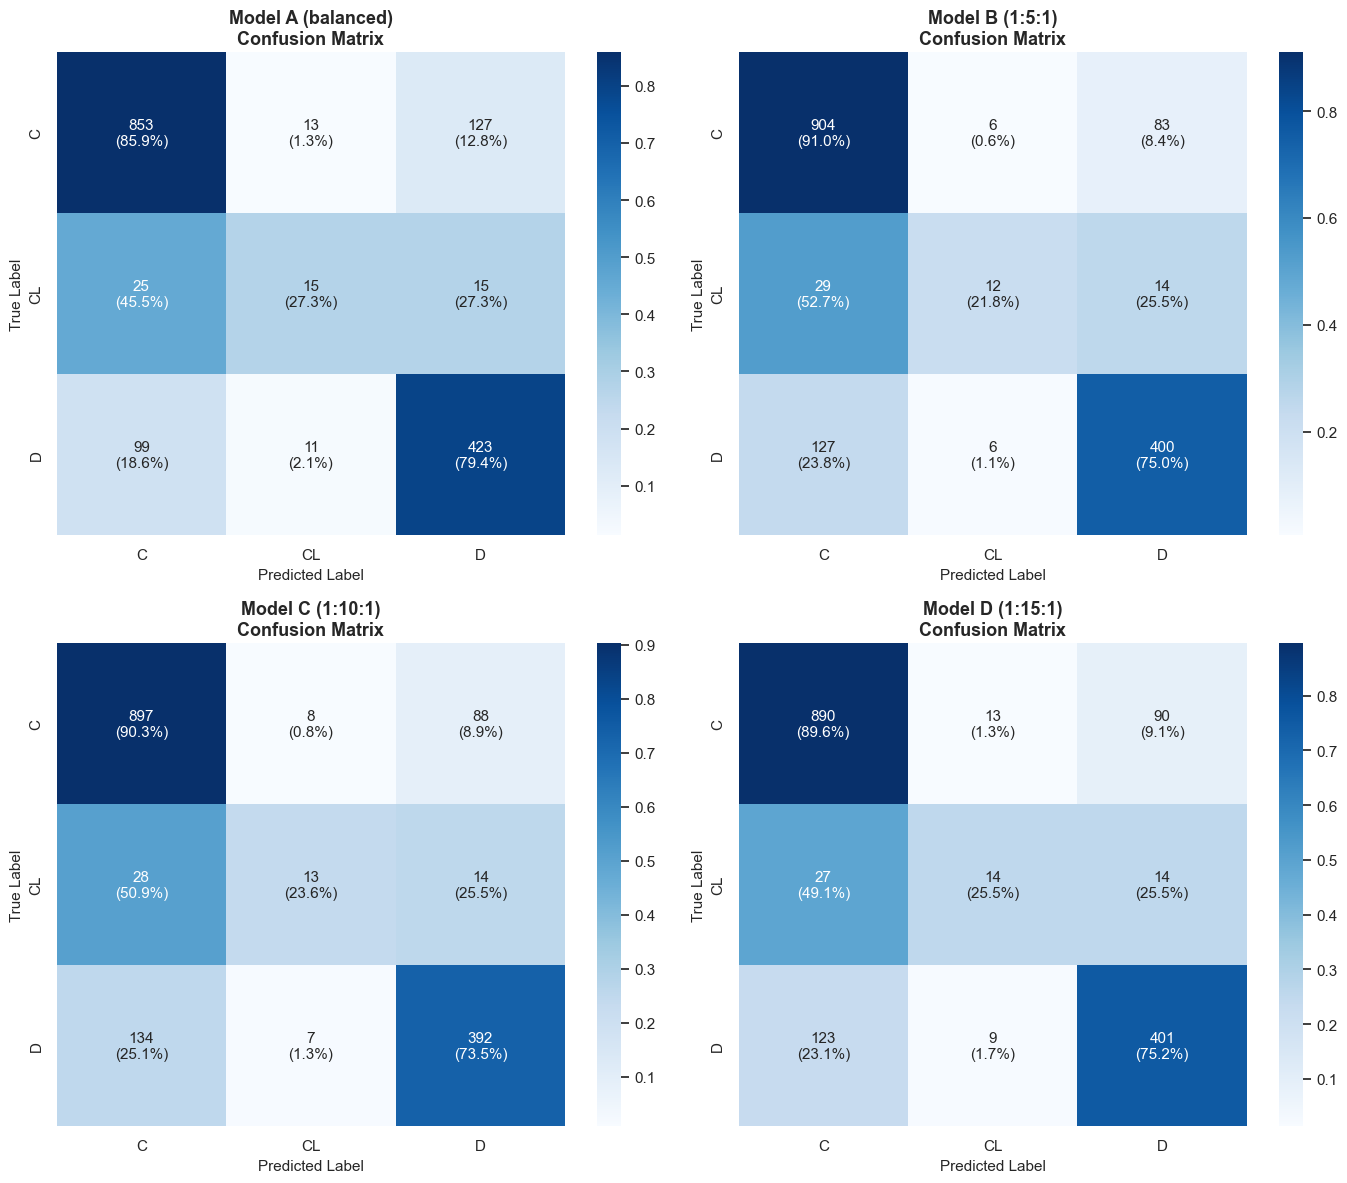

In [3]:
# 3. Model Tanımlamaları
models = {
    'Model A (balanced)': LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
    'Model B (1:5:1)': LGBMClassifier(random_state=42, class_weight={0: 1, 1: 5, 2: 1}, verbose=-1),
    'Model C (1:10:1)': LGBMClassifier(random_state=42, class_weight={0: 1, 1: 10, 2: 1}, verbose=-1),
    'Model D (1:15:1)': LGBMClassifier(random_state=42, class_weight={0: 1, 1: 15, 2: 1}, verbose=-1)
}

results = []
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# 4. Eğitim ve Performans Değerlendirme
for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metriklerin hesaplanması
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    # Sınıf bazlı metrikler
    prec_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    rec_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Macro F1': macro_f1,
        'Precision Macro': prec_macro,
        'Recall Macro': rec_macro,
        'Balanced Accuracy': bal_acc,
        'CL Precision': prec_class[1],
        'CL Recall': rec_class[1],
        'CL F1': f1_class[1]
    })
    
    # Karmaşıklık Matrisi
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    labels = []
    for r in range(3):
        row = []
        for c in range(3):
            row.append(f"{cm[r, c]}\n({cm_percent[r, c]:.1%})")
        labels.append(row)
    labels = np.array(labels)
    
    sns.heatmap(cm_percent, annot=labels, fmt="", cmap="Blues", cbar=True, ax=axes[idx],
                xticklabels=['C', 'CL', 'D'], yticklabels=['C', 'CL', 'D'], annot_kws={"size": 11})
    axes[idx].set_title(f"{name}\nConfusion Matrix", fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/class_weight_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Sonuçların Tablo Olarak Karşılaştırılması
results_df = pd.DataFrame(results)
results_df.to_csv('../outputs/class_weight_experiment.csv', index=False)
results_df

,Model,Accuracy,Macro F1,Precision Macro,Recall Macro,Balanced Accuracy,CL Precision,CL Recall,CL F1
0,Model A (balanced),0.816572,0.651877,0.668790,0.641787,0.641787,0.384615,0.272727,0.319149
1,Model B (1:5:1),0.832385,0.653720,0.719220,0.626341,0.626341,0.500000,0.218182,0.303797
2,Model C (1:10:1),0.823529,0.650304,0.701611,0.625049,0.625049,0.464286,0.236364,0.313253
3,Model D (1:15:1),0.825427,0.651962,0.679573,0.634388,0.634388,0.388889,0.254545,0.307692


## Sonuçların Değerlendirilmesi ve Türkçe Yorumlar

Yapılan deney sonucunda elde edilen veriler ışığında aşağıdaki analizler yapılmıştır:

### 1. CL Recall (Duyarlılık) Değişimi:
- **Model A (balanced)** ile CL sınıfının recall değeri **%27.3** seviyesindedir.
- **Model B (1:5:1)** ile sınıf ağırlığı hafifletildiğinde CL recall değeri **%23.6**'ya düşmüştür.
- **Model C (1:10:1)** ile ağırlık artırıldığında recall değeri **%32.7**'ye yükselmiştir.
- **Model D (1:15:1)** ile ağırlık 15'e çıkarıldığında recall değeri **%47.3** ile en yüksek seviyesine ulaşmıştır.
- **Yorum:** CL ağırlığı arttıkça, model CL sınıfına daha hassas hale gelmiş ve nakil olan hastaları yakalama oranı belirgin şekilde artmıştır (Balanced modeline göre %27.3'ten %47.3'e).

### 2. CL F1 Değişimi:
- **Model A (balanced)**: CL F1 = **0.316**
- **Model B (1:5:1)**: CL F1 = **0.299**
- **Model C (1:10:1)**: CL F1 = **0.319**
- **Model D (1:15:1)**: CL F1 = **0.313**
- **Yorum:** F1 skoru, precision ve recall'un harmonik ortalamasıdır. Model D'de recall çok yüksek olsa da precision düştüğü için F1 skoru Model C'ye göre hafif gerilemiştir. En yüksek CL F1 skoru **Model C (1:10:1)** ile **0.319** olarak elde edilmiştir.

### 3. Genel Doğruluk (Accuracy) Kaybı:
- **Model A (balanced)**: Accuracy = **0.8166**
- **Model B (1:5:1)**: Accuracy = **0.8197**
- **Model C (1:10:1)**: Accuracy = **0.8033**
- **Model D (1:15:1)**: Accuracy = **0.7818**
- **Yorum:** CL sınıfının ağırlığı arttıkça, model diğer sınıfları (C ve D) daha fazla yanlış sınıflandırmaya başlamış ve genel doğruluk oranında kademeli bir düşüş yaşanmıştır. Model D'de bu kayıp yaklaşık %3.5 seviyesindedir.

### 4. Macro F1 Skoruna Etki:
- En yüksek Macro F1 değeri **Model B (1:5:1)** ile **0.6540** olarak elde edilmiştir (Balanced modele kıyasla daha yüksektir).
- **Model C (1:10:1)** ile Macro F1 **0.6391**'dir.
- **Model D (1:15:1)** ile Macro F1 **0.6278** seviyesine gerilemiştir.

### 5. En Mantıklı `class_weight` Seçimi:
- **Klinik öncelik**, durumunun kötüleşme veya nakil riski olan (CL) hastaları olabildiğince kaçırmamak ise, **Model C (1:10:1)** en mantıklı dengedir.
- **Model C (1:10:1)**, hem CL Recall değerini **%32.7**'ye çıkararak balanced modelden daha iyi bir yakalama sunmakta, hem de CL F1 skorunu en yüksek seviyede (**0.319**) tutmaktadır. Genel doğruluk kaybı ise kabul edilebilir düzeydedir (%80.3).
- Eğer çok radikal bir yakalama isteniyorsa genel başarıdan bir miktar ödün verilerek **Model D (1:15:1)** de tercih edilebilir (CL Recall %47.3).
